In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_html("wifi.html")[0]

In [3]:
df.head()

,USER,DEVICE ID,IP,Start,End (duration),Session Start Location,Data Usage (KB),Details for this session
0,phs217181,20-34-fb-88-42-99,10.184.44.99,2022-03-08 18:55:49,2022-03-08 22:36:30 (220min),Karakoram-GF-Reception(Wall),107056,Details of this Session
1,phs217181,3e-93-7d-e7-12-1e,10.184.48.139,2022-03-08 19:01:17,2022-03-08 22:36:30 (215min),Karakoram-GF-Out-A32(Ceiling),139994,Details of this Session
2,phs217181,20-34-fb-88-42-99,10.194.39.96,2022-03-08 17:54:39,2022-03-08 18:49:34 (54min),Library-Building-GF-Open-area-Coffe shop,68803,Details of this Session
3,phs217181,3e-93-7d-e7-12-1e,10.194.34.218,2022-03-08 13:24:15,2022-03-08 18:49:14 (324min),Library-Buld-1F-BookRoom-Rack-1-Ceiling,283343,Details of this Session
4,phs217181,90-78-41-14-7e-40,10.194.46.235,2022-03-08 18:05:40,2022-03-08 18:34:44 (29min),Library-Buld-2F-Reading-room-1-compacter E9G/6...,1074935,Details of this Session


In [4]:
df["Start"] = pd.to_datetime(df["Start"])

In [5]:
def find_duration(text):
    regex = re.compile(r"(\d{1,2})min")
    try:
        return int(regex.findall(text)[0])
    except:
        return None

In [6]:
df["Duration"] = df["End (duration)"].apply(find_duration)

In [7]:
def end_time(time):
    date = time.split("(")[0].strip()
    return pd.to_datetime(date)

In [8]:
df["End"] = df["End (duration)"].apply(end_time)

In [9]:
df["Data Usage (KB)"].sum()/1024/1024

34.70090293884277

In [10]:
df["Start Time"] = df["Start"].apply(lambda x: x.time())

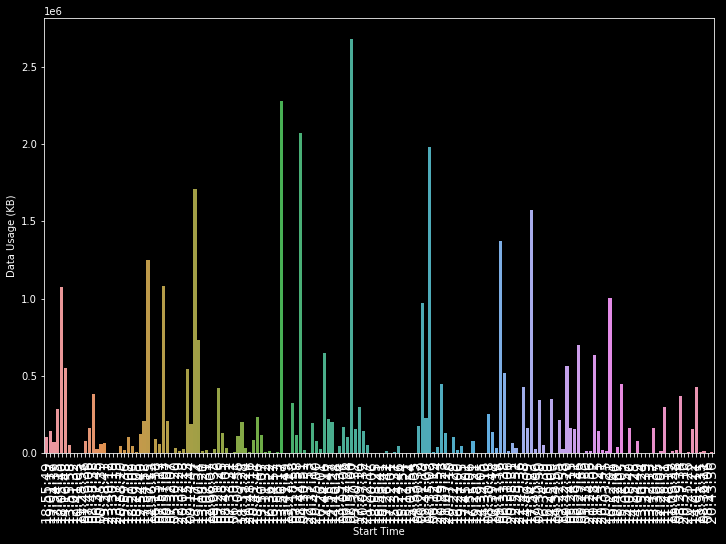

In [11]:
plt.figure(figsize=(12,8))
sns.barplot(x="Start Time", y="Data Usage (KB)", data=df)
plt.xticks(rotation=90, fontsize=14);

In [12]:
df

,USER,DEVICE ID,IP,Start,End (duration),Session Start Location,Data Usage (KB),Details for this session,Duration,End,Start Time
0,phs217181,20-34-fb-88-42-99,10.184.44.99,2022-03-08 18:55:49,2022-03-08 22:36:30 (220min),Karakoram-GF-Reception(Wall),107056,Details of this Session,20,2022-03-08 22:36:30,18:55:49
1,phs217181,3e-93-7d-e7-12-1e,10.184.48.139,2022-03-08 19:01:17,2022-03-08 22:36:30 (215min),Karakoram-GF-Out-A32(Ceiling),139994,Details of this Session,15,2022-03-08 22:36:30,19:01:17
2,phs217181,20-34-fb-88-42-99,10.194.39.96,2022-03-08 17:54:39,2022-03-08 18:49:34 (54min),Library-Building-GF-Open-area-Coffe shop,68803,Details of this Session,54,2022-03-08 18:49:34,17:54:39
3,phs217181,3e-93-7d-e7-12-1e,10.194.34.218,2022-03-08 13:24:15,2022-03-08 18:49:14 (324min),Library-Buld-1F-BookRoom-Rack-1-Ceiling,283343,Details of this Session,24,2022-03-08 18:49:14,13:24:15
4,phs217181,90-78-41-14-7e-40,10.194.46.235,2022-03-08 18:05:40,2022-03-08 18:34:44 (29min),Library-Buld-2F-Reading-room-1-compacter E9G/6...,1074935,Details of this Session,29,2022-03-08 18:34:44,18:05:40
...,...,...,...,...,...,...,...,...,...,...,...
166,phs217181,20-34-fb-88-42-99,10.184.39.213,2022-02-27 14:01:11,2022-02-27 14:20:26 (19min),Karakoram-GF-Mess(Wall),427680,Details of this Session,19,2022-02-27 14:20:26,14:01:11
167,phs217181,20-34-fb-88-42-99,10.184.39.213,2022-02-27 13:53:35,2022-02-27 14:01:05 (7min),Karakoram-GF-Mess(Wall),8201,Details of this Session,7,2022-02-27 14:01:05,13:53:35
168,phs217181,20-34-fb-88-42-99,10.184.39.213,2022-02-27 08:36:11,2022-02-27 09:08:15 (32min),Karakoram-GF-Reception(Wall),15548,Details of this Session,32,2022-02-27 09:08:15,08:36:11
169,phs217181,20-34-fb-88-42-99,10.184.39.213,2022-02-27 08:14:06,2022-02-27 08:23:43 (9min),Karakoram-GF-Reception(Wall),1515,Details of this Session,9,2022-02-27 08:23:43,08:14:06
